In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torchvision
from torchvision import datasets, models, transforms
import numpy as np
import matplotlib.pyplot as plt
import time
import os
import copy
from sklearn.metrics import classification_report, confusion_matrix
from tqdm import tqdm
import pandas as pd
import seaborn as sns

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Check if GPU is available
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [2]:
# Data augmentation and normalization for training
# Just normalization for validation
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(30),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'valid': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

data_dir = 'C:\\laragon\\www\\ProjImages\\dataset'
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x),
                  data_transforms[x])
                  for x in ['train', 'valid']}
dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=32,
                                             shuffle=True, num_workers=4)
              for x in ['train', 'valid']}
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'valid']}
class_names = image_datasets['train'].classes

print(f"Classes: {class_names}")
print(f"Train dataset size: {dataset_sizes['train']}")
print(f"Validation dataset size: {dataset_sizes['valid']}")

Classes: ['Black Pod Rot Disease', 'Fito Disease', 'Healthy', 'Monilia Disease', 'Unknow Data']
Train dataset size: 51170
Validation dataset size: 51170


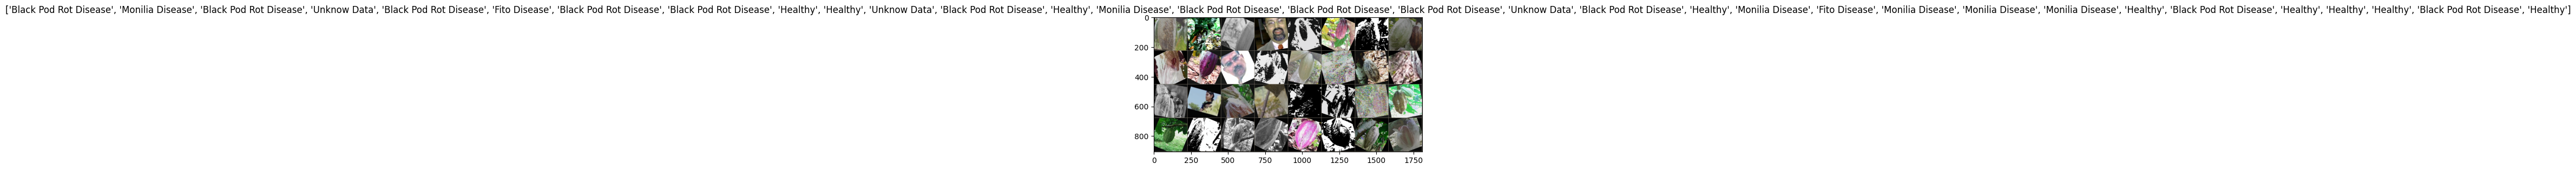

In [3]:
def imshow(inp, title=None):
    """Display image for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)  # pause a bit so that plots are updated

# Get a batch of training data
inputs, classes = next(iter(dataloaders['train']))

# Make a grid from batch
out = torchvision.utils.make_grid(inputs)

imshow(out, title=[class_names[x] for x in classes])

In [4]:
def initialize_model(num_classes):
    # Load pretrained ResNet18
    model = models.resnet18(pretrained=True)
    
    # Freeze all layers first
    for param in model.parameters():
        param.requires_grad = False
    
    # Get the number of inputs to the final layer
    num_ftrs = model.fc.in_features
    
    # Replace the final fully connected layer
    model.fc = nn.Linear(num_ftrs, num_classes)
    
    # Unfreeze some later layers for fine-tuning (optional)
    # Here we unfreeze the last two residual blocks
    for name, param in model.named_parameters():
        if 'layer4' in name or 'layer3' in name:
            param.requires_grad = True
    
    return model

model = initialize_model(len(class_names))
model = model.to(device)

print(model)

c:\laragon\www\env\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\laragon\www\env\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [5]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=50):
    since = time.time()

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    # To store training history
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(num_epochs):
        print(f'Epoch {epoch}/{num_epochs - 1}')
        print('-' * 10)

        # Each epoch has a training and validation phase
        for phase in ['train', 'valid']:
            if phase == 'train':
                model.train()  # Set model to training mode
            else:
                model.eval()   # Set model to evaluate mode

            running_loss = 0.0
            running_corrects = 0

            # Iterate over data
            for inputs, labels in tqdm(dataloaders[phase], desc=phase):
                inputs = inputs.to(device)
                labels = labels.to(device)

                # Zero the parameter gradients
                optimizer.zero_grad()

                # Forward
                # Track history if only in train
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    # Backward + optimize only if in training phase
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                # Statistics
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            if phase == 'train':
                scheduler.step()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            # Store history
            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc.cpu().numpy())
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc.cpu().numpy())

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            # Deep copy the model if it's the best so far
            if phase == 'valid' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

        print()

    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best val Acc: {best_acc:4f}')

    # Load best model weights
    model.load_state_dict(best_model_wts)
    
    return model, history

In [6]:
# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()

# Observe that only parameters of final layer are being optimized as
# opposed to before when we were fine-tuning all layers
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Decay LR by a factor of 0.1 every 7 epochs
exp_lr_scheduler = lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

# Train the model
model, history = train_model(model, criterion, optimizer, exp_lr_scheduler, num_epochs=25)

Epoch 0/24
----------


train: 100%|██████████| 1600/1600 [52:19<00:00,  1.96s/it] 


train Loss: 0.5303 Acc: 0.7613


valid: 100%|██████████| 1600/1600 [29:09<00:00,  1.09s/it]


valid Loss: 0.2577 Acc: 0.8850

Epoch 1/24
----------


...

valid Loss: 0.0709 Acc: 0.9681

Epoch 24/24
----------


train: 100%|██████████| 1600/1600 [36:32<00:00,  1.37s/it]


train Loss: 0.1753 Acc: 0.9214


valid: 100%|██████████| 1600/1600 [20:07<00:00,  1.33it/s]

valid Loss: 0.0706 Acc: 0.9677

Training complete in 1744m 40s
Best val Acc: 0.968145


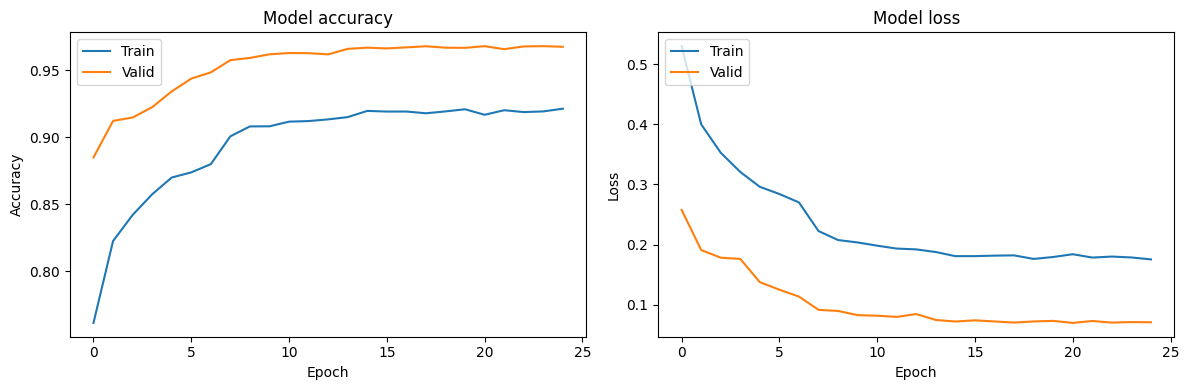

In [7]:
def plot_training_history(history):
    plt.figure(figsize=(12, 4))
    
    # Plot training & validation accuracy values
    plt.subplot(1, 2, 1)
    plt.plot(history['train_acc'])
    plt.plot(history['val_acc'])
    plt.title('Model accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Valid'], loc='upper left')
    
    # Plot training & validation loss values
    plt.subplot(1, 2, 2)
    plt.plot(history['train_loss'])
    plt.plot(history['val_loss'])
    plt.title('Model loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Valid'], loc='upper left')
    
    plt.tight_layout()
    plt.show()

plot_training_history(history)

Evaluating: 100%|██████████| 1600/1600 [22:29<00:00,  1.19it/s]


Classification Report:
                       precision    recall  f1-score   support

Black Pod Rot Disease       0.96      0.94      0.95     15376
         Fito Disease       0.98      0.99      0.98      6420
              Healthy       0.96      0.97      0.96     19783
      Monilia Disease       0.98      0.98      0.98      6300
          Unknow Data       1.00      1.00      1.00      3291

             accuracy                           0.97     51170
            macro avg       0.98      0.98      0.98     51170
         weighted avg       0.97      0.97      0.97     51170



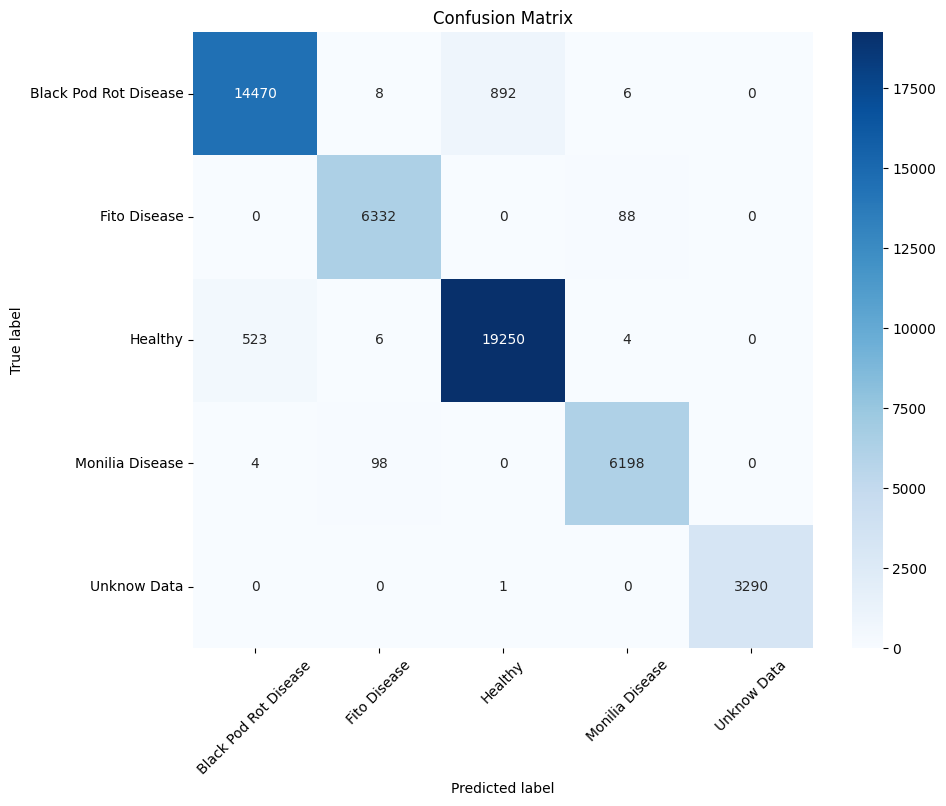

In [8]:
def evaluate_model(model, dataloader):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in tqdm(dataloader, desc='Evaluating'):
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    # Classification report
    print("Classification Report:")
    print(classification_report(all_labels, all_preds, target_names=class_names))
    
    # Confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.show()

evaluate_model(model, dataloaders['valid'])

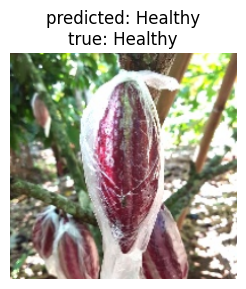

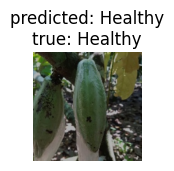

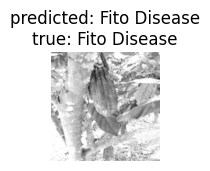

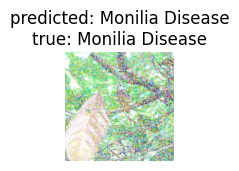

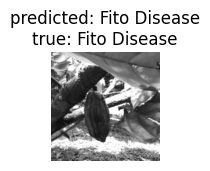

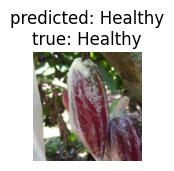

In [9]:
def visualize_predictions(model, num_images=6):
    model.eval()
    images_so_far = 0
    plt.figure(figsize=(15, 10))
    
    with torch.no_grad():
        for i, (inputs, labels) in enumerate(dataloaders['valid']):
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            for j in range(inputs.size()[0]):
                images_so_far += 1
                ax = plt.subplot(num_images//2, 2, images_so_far)
                ax.axis('off')
                ax.set_title(f'predicted: {class_names[preds[j]]}\ntrue: {class_names[labels[j]]}')
                imshow(inputs.cpu().data[j])
                
                if images_so_far == num_images:
                    return

visualize_predictions(model)

In [10]:
# Save the entire model
torch.save(model, 'cacao_disease_resnet.pth')

# Alternatively, save just the state_dict (recommended)
torch.save(model.state_dict(), 'cacao_disease_resnet_state_dict.pth')

print("Model saved successfully!")

Model saved successfully!


In [11]:
def predict_image(image_path, model, class_names):
    model.eval()
    
    # Load and preprocess the image
    image = Image.open(image_path)
    preprocess = data_transforms['val']
    image_tensor = preprocess(image)
    image_tensor = image_tensor.unsqueeze(0)  # Add batch dimension
    
    # Move to device
    image_tensor = image_tensor.to(device)
    
    # Predict
    with torch.no_grad():
        output = model(image_tensor)
        _, predicted_idx = torch.max(output, 1)
        predicted_class = class_names[predicted_idx.item()]
    
    # Show image and prediction
    plt.imshow(image)
    plt.title(f"Predicted: {predicted_class}")
    plt.axis('off')
    plt.show()
    
    return predicted_class

# Example usage:
# predict_image('test_tomato_leaf.jpg', model, class_names)


In [13]:
from PIL import Image
import matplotlib.pyplot as plt
import torch
from torchvision import transforms

# Load model (using Solution 1)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = torch.load('cacao_disease_resnet.pth', 
                 map_location=device, 
                 weights_only=False)  # Security override
model.eval()

# Define transforms and classes
data_transforms = {
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
}

class_names = ['Anaji', 'Banana Lady Finger ( Señorita )', 'Banana Red', 'Bichi', 'Canvendish(Bungulan)', 'Lakatan', 'Saba', 'Sabri Kola']

def predict_image(image_path):
    try:
        # Preprocess
        img = Image.open(image_path).convert('RGB')
        img_tensor = data_transforms['val'](img).unsqueeze(0).to(device)
        
        # Predict
        with torch.no_grad():
            output = model(img_tensor)
            _, pred = torch.max(output, 1)
            prob = torch.nn.functional.softmax(output, dim=1)[0] * 100
            
        # Display
        plt.imshow(img)
        plt.title(f"Predicted: {class_names[pred.item()]}\nConfidence: {prob[pred].item():.2f}%")
        plt.axis('off')
        plt.show()
        
        return class_names[pred.item()]
    
    except Exception as e:
        print(f"Error: {e}")
        return None

# Test prediction
predict_image('C:/laragon/www/ProjImages/test/r.jpg')


Error: [Errno 2] No such file or directory: 'C:/laragon/www/ProjImages/test/r.jpg'


In [ ]:
# Test prediction
predict_image('C:/laragon/www/ProjImages/test/10.png')
